In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Load Dataset
df = pd.read_csv('/content/sample_data/data.csv')

# View First 5 Rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [13]:
# Dataset Exploration

# 1.Shape of Dataset
print("Shape of Dataset:")
print(df.shape)

# 2.Display 5 Random Samples
print("5 Random Samples:")
print(df.sample(5))

# 3.Dataset Information
print("Dataset Info:")
df.info()

# 4.Statistical Summary
print("Statistical Summary:")
print(df.describe())

# 5.Number of unique values in each column.
print("Number of Unique Values in Each Column:")
print(df.nunique())

# 6.Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# 7.Check Duplicate Rows
print("Duplicate Rows:")
print(df.duplicated().sum())

# 8.Memory Usage
print("Memory Usage:")
print(df.memory_usage())

# 9.Check Skewness
print("Skewness:")
print(df.skew(numeric_only=True))

Shape of Dataset:
(569, 33)
5 Random Samples:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
556   924964         B        10.16         19.59           64.73      311.7   
6     844359         M        18.25         19.98          119.60     1040.0   
264   889719         M        17.19         22.07          111.60      928.3   
450  9111596         B        11.87         21.54           76.83      432.0   
37    854941         B        13.03         18.42           82.61      523.8   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
556          0.10030           0.07504        0.005025              0.01116   
6            0.09463           0.10900        0.112700              0.07400   
264          0.09726           0.08995        0.090610              0.06527   
450          0.06613           0.10640        0.087770              0.02386   
37           0.08983           0.03766        0.025620              0.02923   

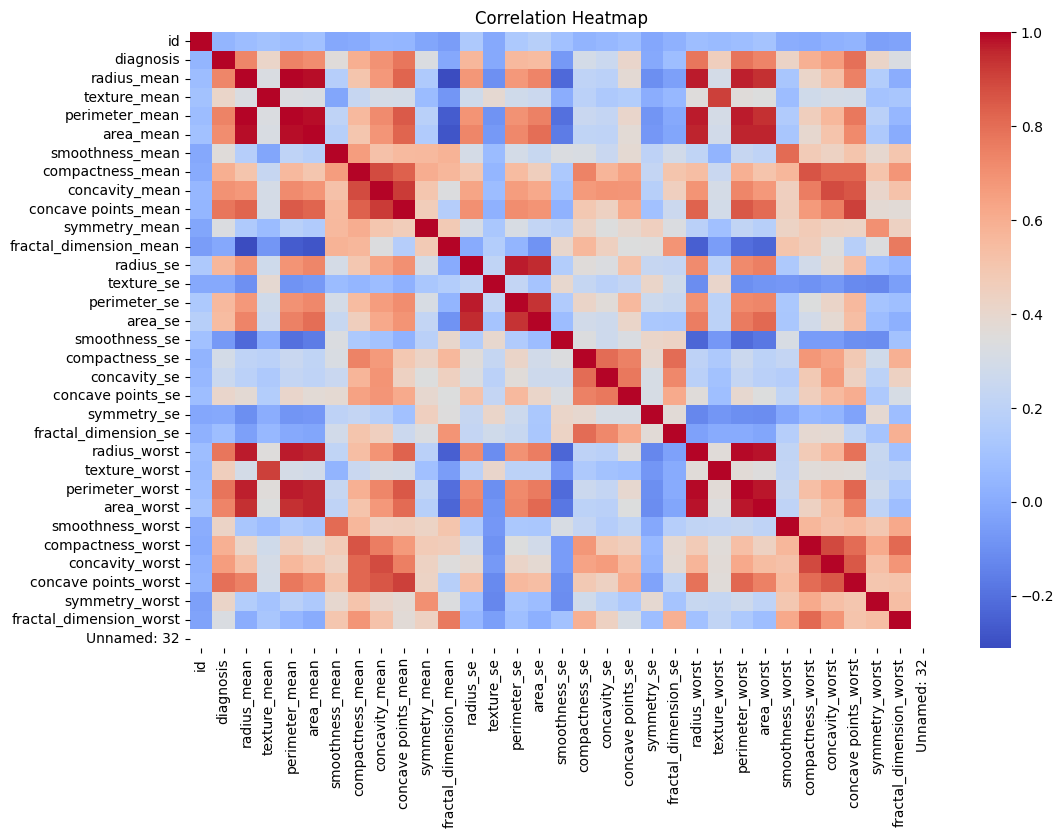

In [17]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

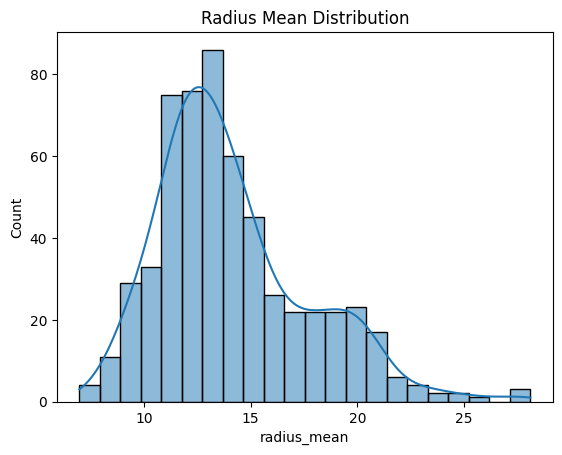

In [38]:
# Distribution Plot
sns.histplot(df['radius_mean'], kde=True)
plt.title("Radius Mean Distribution")
plt.show()

In [33]:
df.drop(columns=['Unnamed: 32'], inplace=True, errors='ignore')
df.drop_duplicates(inplace=True)

In [34]:
# Encoding Categorical Data
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [35]:
# Feature Selection
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

In [39]:
# Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
# Split Data into Training and Testing Sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [41]:
# Logistic Regression Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [43]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [45]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC:", auc)

Accuracy: 0.9767441860465116
Precision: 0.9285714285714286
Recall: 1.0
F1 Score: 0.9629629629629629
AUC: 0.9993589743589744


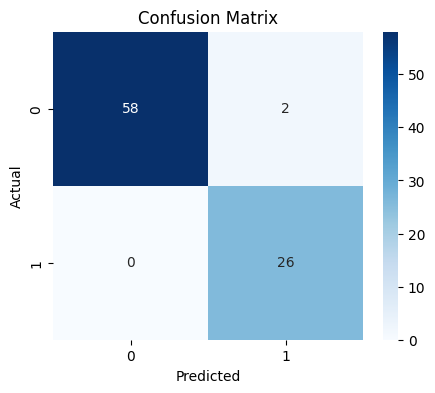

In [46]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

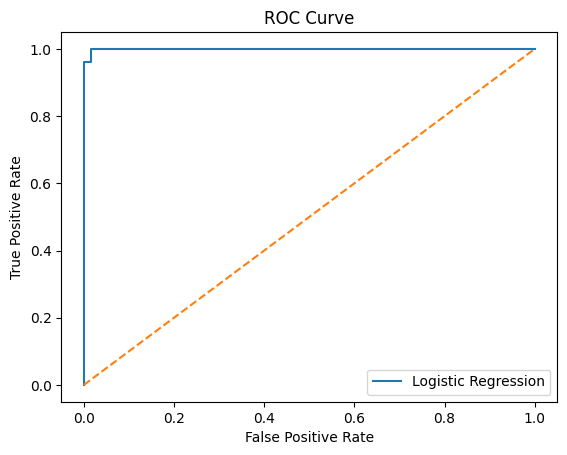

In [47]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [48]:
# Sample Predictions
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob
})

results.head(10)

,Actual,Predicted,Probability
0,0,0,0.000002
1,0,0,0.009960
2,0,0,0.000145
3,1,1,0.999002
4,0,0,0.000043
5,0,0,0.000036
6,1,1,0.996097
7,0,0,0.008324
8,0,0,0.036338
9,0,0,0.150453


In [49]:
# Conclusion:
# The Logistic Regression model was successfully implemented on the Breast Cancer Classification dataset. Exploratory Data Analysis (EDA) was performed to understand the dataset structure, identify missing values, analyze feature distributions, detect outliers, and study correlations between features.
# During preprocessing, missing values and duplicate records were handled, categorical data was encoded, and numerical features were normalized using standardization techniques. The dataset was then divided into training, validation, and testing sets to ensure proper model evaluation.
# The Logistic Regression model was trained successfully and evaluated using multiple classification metrics including Accuracy, Precision, Recall, F1-Score, and AUC Score. The confusion matrix and ROC curve demonstrated that the model performed effectively in distinguishing between malignant and benign tumor cases.
# The model achieved high prediction performance, indicating that Logistic Regression is a suitable algorithm for binary classification problems such as breast cancer detection. The results also showed that proper preprocessing and feature scaling significantly improve model performance and prediction reliability.
